# ACLib cplex_regions200: partial fixed-depth analysis

Analysis of random-forest depths **5, 10, 15, 20, 25, 30, and 40** over five paired SMAC seeds. The jobs were canceled before the planned 10,000 trials, so this notebook loads the incumbent trajectories saved by SMAC and compares every run at their largest common completed-trial budget. Lower PAR10 is better.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DEPTHS = (5, 10, 15, 20, 25, 30, 40)
SMAC_SEEDS = tuple(range(5))
PLANNED_TRIALS = 10_000
COLORS = dict(zip(DEPTHS, plt.cm.viridis(np.linspace(0.05, 0.95, len(DEPTHS)))))

candidates = [
    Path.cwd(),
    Path.cwd() / 'experiments/aclib/cplex_regions200_surrogate/02_full_run',
]
HERE = next((path.resolve() for path in candidates if (path / 'submit_experiment.py').is_file()), None)
if HERE is None:
    raise FileNotFoundError('Run from the notebook directory or repository root.')
RESULTS = HERE / 'results'
print('Results:', RESULTS)

Results: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/aclib/cplex_regions200_surrogate/02_full_run/results


## Load partial trajectories and run status

The completion markers still say `running` because the jobs were canceled. A run is therefore considered usable whenever `runhistory.json` and a non-empty trajectory in `intensifier.json` exist.

In [2]:
def finished_trials(path: Path) -> int:
    """Read the runhistory header without loading its large data array."""
    if not path.is_file():
        return 0
    with path.open(encoding='utf-8') as handle:
        header = handle.read(512)
    match = re.search(r'"finished"\s*:\s*(\d+)', header)
    return int(match.group(1)) if match else 0


rows = []
curves = {}

for depth in DEPTHS:
    for seed in SMAC_SEEDS:
        directory = RESULTS / f'depth_{depth}' / str(seed)
        marker_path = directory / 'completed.json'
        intensifier_path = directory / 'intensifier.json'
        optimization_path = directory / 'optimization.json'

        marker = json.loads(marker_path.read_text()) if marker_path.is_file() else {}
        intensifier = json.loads(intensifier_path.read_text()) if intensifier_path.is_file() else {}
        optimization = json.loads(optimization_path.read_text()) if optimization_path.is_file() else {}
        n_finished = min(finished_trials(directory / 'runhistory.json'), PLANNED_TRIALS)
        trajectory = intensifier.get('trajectory', [])

        event_trials = np.asarray([int(event['trial']) for event in trajectory], dtype=int)
        event_costs = np.asarray([float(event['costs'][0]) for event in trajectory], dtype=float)
        usable = n_finished > 0 and len(event_trials) > 0

        if usable:
            order = np.argsort(event_trials)
            event_trials = event_trials[order]
            event_costs = event_costs[order]
            curve = np.full(n_finished, np.nan)
            for index, (trial, cost) in enumerate(zip(event_trials, event_costs)):
                start = max(trial - 1, 0)
                stop = event_trials[index + 1] - 1 if index + 1 < len(event_trials) else n_finished
                curve[start:min(stop, n_finished)] = cost
            curves[(depth, seed)] = curve

        rows.append({
            'depth': depth,
            'smac_seed': seed,
            'marker_state': marker.get('state', 'missing'),
            'finished_trials': n_finished,
            'progress_%': 100 * n_finished / PLANNED_TRIALS,
            'trajectory_changes': len(trajectory),
            'current_incumbent': event_costs[-1] if usable else np.nan,
            'last_improvement_trial': event_trials[-1] if usable else np.nan,
            'used_walltime_hours': float(optimization.get('used_walltime', np.nan)) / 3600,
            'usable': usable,
        })

status = pd.DataFrame(rows)
if not curves:
    raise FileNotFoundError(f'No usable incumbent trajectories found below {RESULTS}.')

missing = [(depth, seed) for depth in DEPTHS for seed in SMAC_SEEDS if (depth, seed) not in curves]
common_trials = min(len(curve) for curve in curves.values())
expected_runs = len(DEPTHS) * len(SMAC_SEEDS)

progress = status.pivot(index='depth', columns='smac_seed', values='finished_trials')
progress.index.name = 'Depth'
progress.columns.name = 'SMAC seed'
display(progress.style.format('{:,}').background_gradient(cmap='Blues'))
print(f'Usable runs: {len(curves)} / {expected_runs}')
print(f'Missing depth/seed pairs: {missing or "none"}')
print(f'Common comparison budget: {common_trials:,} completed trials')
display(
    status.groupby('depth').agg(
        runs=('usable', 'sum'),
        min_trials=('finished_trials', 'min'),
        max_trials=('finished_trials', 'max'),
        mean_walltime_hours=('used_walltime_hours', 'mean'),
    ).style.format({'mean_walltime_hours': '{:.2f}'})
)

SMAC seed,0,1,2,3,4
Depth,,,,,
5,"4,421","4,092","4,456","4,371","4,466"
10,"3,684","3,605","4,266","4,774","4,096"
15,"4,625","4,301","4,965","4,251","3,443"
20,"4,053","4,249","4,654","5,045","3,376"
25,"4,341","4,367","4,090","4,177","3,422"
30,"4,995","4,162","4,528","4,463","3,505"
40,"5,025","4,242","4,546","4,760","3,531"


Usable runs: 35 / 35
Missing depth/seed pairs: none
Common comparison budget: 3,376 completed trials


,runs,min_trials,max_trials,mean_walltime_hours
depth,,,,
5,5,4092,4466,16.62
10,5,3605,4774,16.63
15,5,3443,4965,16.57
20,5,3376,5045,16.37
25,5,3422,4367,16.36
30,5,3505,4995,16.37
40,5,3531,5025,16.37


## Optimization progress with 95% confidence intervals

The solid line is the mean incumbent PAR10 across the five paired SMAC seeds. Shading is a two-sided 95% Student-t confidence interval for that mean. Curves stop at the largest trial budget reached by every usable run, which keeps the depth comparison paired and avoids favoring runs that happened to continue longer.

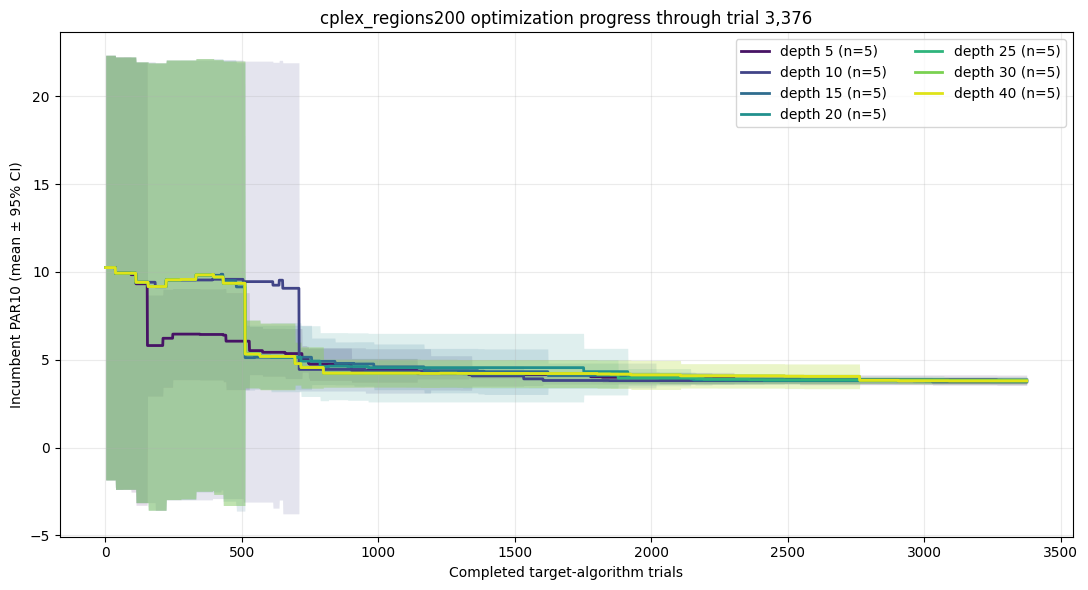

In [3]:
T_CRIT_95 = {2: 12.7062047364, 3: 4.3026527297, 4: 3.1824463053, 5: 2.7764451052}


def curve_summary(depth: int):
    series = [curves[(depth, seed)][:common_trials] for seed in SMAC_SEEDS if (depth, seed) in curves]
    array = np.vstack(series)
    mean = array.mean(axis=0)
    if len(array) < 2:
        half_width = np.zeros_like(mean)
    else:
        critical = T_CRIT_95.get(len(array), 1.96)
        half_width = critical * array.std(axis=0, ddof=1) / np.sqrt(len(array))
    return np.arange(1, common_trials + 1), mean, half_width, len(array)


fig, ax = plt.subplots(figsize=(11, 6))
for depth in DEPTHS:
    if not any((depth, seed) in curves for seed in SMAC_SEEDS):
        continue
    trial, mean, half_width, n = curve_summary(depth)
    color = COLORS[depth]
    ax.plot(trial, mean, color=color, linewidth=2, label=f'depth {depth} (n={n})')
    ax.fill_between(trial, mean - half_width, mean + half_width, color=color, alpha=0.14, linewidth=0)

ax.set(
    xlabel='Completed target-algorithm trials',
    ylabel='Incumbent PAR10 (mean ± 95% CI)',
    title=f'cplex_regions200 optimization progress through trial {common_trials:,}',
)
ax.grid(alpha=0.25)
ax.legend(ncols=2)
fig.tight_layout()
plt.show()

## Incumbent distributions at the common budget

Every point is one SMAC seed evaluated at the same completed-trial budget. The paired panel connects equal seeds across depths.

depth,5,10,15,20,25,30,40
smac_seed,,,,,,,
0,3.5824,3.8174,3.815,3.7448,3.78,3.7716,3.7394
1,4.1334,3.5365,3.7593,3.7891,3.8735,3.8878,3.7432
2,3.7583,3.8731,3.9024,3.9215,3.9335,3.8613,3.8613
3,3.7058,3.8273,3.7992,3.7837,4.0254,3.9872,3.9872
4,4.0223,3.638,3.6192,3.6059,3.6059,3.6059,3.6059


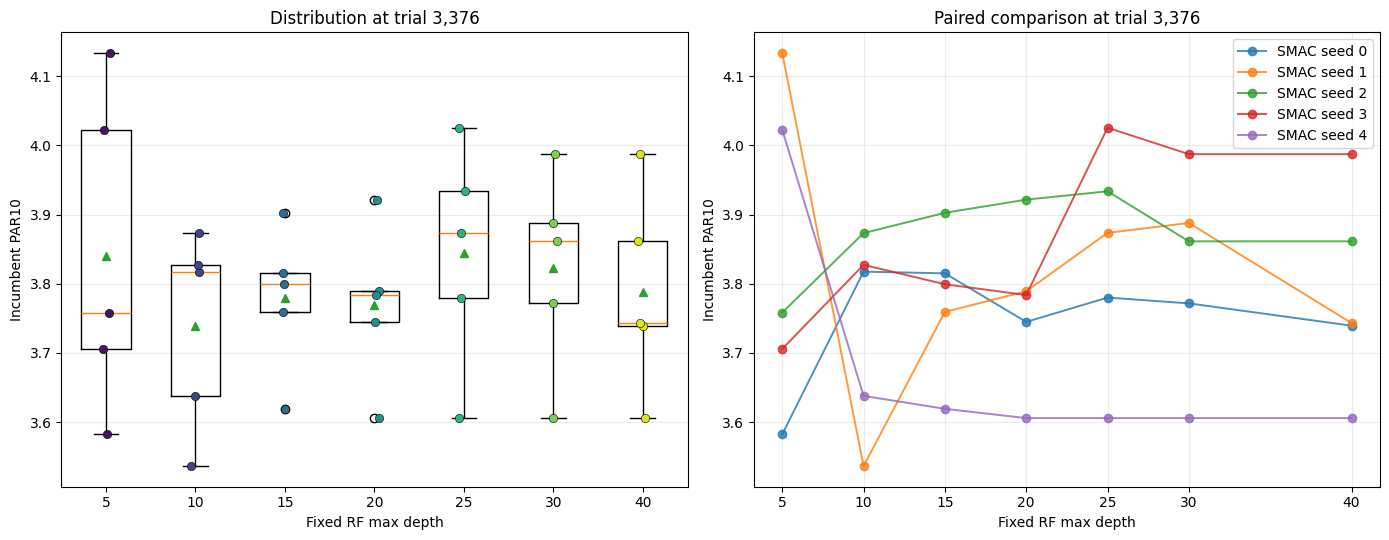

In [4]:
comparison_rows = [
    {
        'depth': depth,
        'smac_seed': seed,
        'incumbent_cost': float(curve[common_trials - 1]),
    }
    for (depth, seed), curve in curves.items()
]
comparison = pd.DataFrame(comparison_rows)
available_depths = [depth for depth in DEPTHS if depth in comparison['depth'].unique()]
paired = comparison.pivot(index='smac_seed', columns='depth', values='incumbent_cost').reindex(columns=available_depths)
display(paired.style.format('{:,.5g}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
box_data = [comparison.query('depth == @depth')['incumbent_cost'].to_numpy() for depth in available_depths]
axes[0].boxplot(box_data, tick_labels=[str(depth) for depth in available_depths], showmeans=True, widths=0.55)
rng = np.random.default_rng(7)
for position, (depth, values) in enumerate(zip(available_depths, box_data), start=1):
    jitter = rng.uniform(-0.055, 0.055, size=len(values))
    axes[0].scatter(
        position + jitter, values, color=COLORS[depth], edgecolor='black', linewidth=0.4, zorder=3
    )
axes[0].set(
    xlabel='Fixed RF max depth',
    ylabel='Incumbent PAR10',
    title=f'Distribution at trial {common_trials:,}',
)
axes[0].grid(axis='y', alpha=0.25)

for seed, row in paired.iterrows():
    valid = row.dropna()
    axes[1].plot(valid.index, valid.values, marker='o', linewidth=1.4, alpha=0.8, label=f'SMAC seed {seed}')
axes[1].set(
    xlabel='Fixed RF max depth',
    ylabel='Incumbent PAR10',
    title=f'Paired comparison at trial {common_trials:,}',
)
axes[1].set_xticks(available_depths)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## Checkpoint comparison

These panels show whether the preferred depth changes over the available optimization budget. They share one y-axis scale for direct comparison.

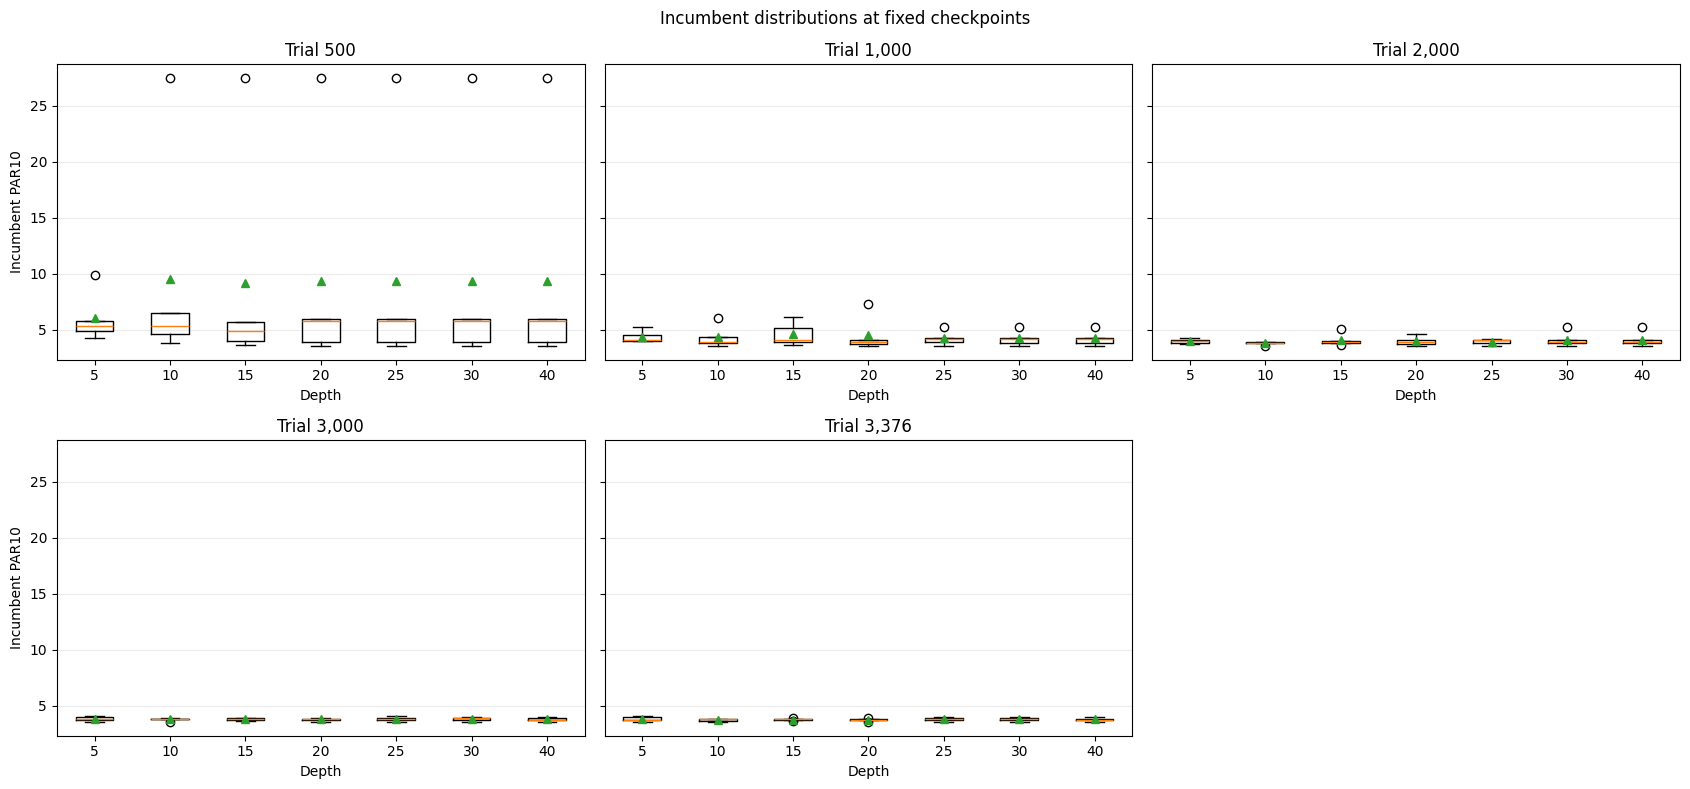

In [5]:
base_checkpoints = (500, 1_000, 2_000, 3_000, 4_000, 5_000)
checkpoints = tuple(value for value in base_checkpoints if value <= common_trials)
if common_trials not in checkpoints:
    checkpoints += (common_trials,)

checkpoint_rows = []
for (depth, seed), curve in curves.items():
    for checkpoint in checkpoints:
        checkpoint_rows.append({
            'depth': depth,
            'smac_seed': seed,
            'checkpoint': checkpoint,
            'incumbent_cost': float(curve[checkpoint - 1]),
        })
checkpoint_df = pd.DataFrame(checkpoint_rows)

ncols = 3
nrows = int(np.ceil(len(checkpoints) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4 * nrows), sharey=True, squeeze=False)
for ax, checkpoint in zip(axes.flat, checkpoints):
    subset = checkpoint_df.query('checkpoint == @checkpoint')
    values = [subset.query('depth == @depth')['incumbent_cost'].to_numpy() for depth in available_depths]
    ax.boxplot(values, tick_labels=[str(depth) for depth in available_depths], showmeans=True)
    ax.set_title(f'Trial {checkpoint:,}')
    ax.set_xlabel('Depth')
    ax.grid(axis='y', alpha=0.25)
for ax in axes[:, 0]:
    ax.set_ylabel('Incumbent PAR10')
for ax in axes.flat[len(checkpoints):]:
    ax.axis('off')
fig.suptitle('Incumbent distributions at fixed checkpoints')
fig.tight_layout()
plt.show()

## Numerical summary and paired ranks

Ranks are computed within each SMAC seed at the common budget; rank 1 is best.

In [6]:
summary = comparison.groupby('depth')['incumbent_cost'].agg(
    n='count', mean='mean', std='std', median='median', minimum='min', maximum='max'
)
summary['sem'] = summary['std'] / np.sqrt(summary['n'])
summary['ci95_half_width'] = [
    T_CRIT_95.get(int(n), 1.96) * sem for n, sem in zip(summary['n'], summary['sem'])
]

seed_ranks = paired.rank(axis=1, method='average', ascending=True)
rank_summary = pd.DataFrame({
    'mean_rank': seed_ranks.mean(),
    'median_rank': seed_ranks.median(),
    'times_best': (seed_ranks == 1).sum(),
})
summary = summary.join(rank_summary).sort_values(['mean_rank', 'mean'])

display(summary.style.format({
    'mean': '{:,.5g}',
    'std': '{:,.5g}',
    'median': '{:,.5g}',
    'minimum': '{:,.5g}',
    'maximum': '{:,.5g}',
    'sem': '{:,.5g}',
    'ci95_half_width': '{:,.5g}',
    'mean_rank': '{:.2f}',
    'median_rank': '{:.2f}',
}))
print('Depth ranks within each paired SMAC seed:')
display(seed_ranks)

,n,mean,std,median,minimum,maximum,sem,ci95_half_width,mean_rank,median_rank,times_best
depth,,,,,,,,,,,
40,5,3.7874,0.14368,3.7432,3.6059,3.9872,0.064257,0.17841,2.90,2.50,0
5,5,3.8404,0.22933,3.7583,3.5824,4.1334,0.10256,0.28475,3.40,1.00,3
20,5,3.769,0.113,3.7837,3.6059,3.9215,0.050535,0.14031,3.50,3.00,0
30,5,3.8227,0.14352,3.8613,3.6059,3.9872,0.064186,0.17821,4.10,4.00,0
10,5,3.7385,0.14415,3.8174,3.5365,3.8731,0.064465,0.17898,4.40,4.00,1
15,5,3.779,0.10351,3.7992,3.6192,3.9024,0.046291,0.12852,4.40,5.00,0
25,5,3.8437,0.16015,3.8735,3.6059,4.0254,0.071623,0.19886,5.30,5.00,0


Depth ranks within each paired SMAC seed:


depth,5,10,15,20,25,30,40
smac_seed,,,,,,,
0,1.0,7.0,6.0,3.0,5.0,4.0,2.0
1,7.0,1.0,3.0,4.0,5.0,6.0,2.0
2,1.0,4.0,5.0,6.0,7.0,2.5,2.5
3,1.0,4.0,3.0,2.0,7.0,5.5,5.5
4,7.0,6.0,5.0,2.5,2.5,2.5,2.5


With only five seeds, treat small differences cautiously. Use the common-budget plots and paired ranks for depth comparisons; the `current_incumbent` values in the status data frame are useful for inspecting individual runs, but are not directly comparable because the canceled runs reached different trial counts.